# STEP → coil centerlines for simsopt

Recover filament centerlines from the CFQS modular-coil STEP assembly and
return them as `coil_gammas_old`: four `(N_CURVE_SAMPLE, 3)` arrays in **metres**.

## What the STEP file actually stores

SolidWorks exported **B-Rep solids**, not sweep construction history. Each
`MC*-CON` body is a rectangular tube whose sides are degree-(5, 1) NURBS
patches. The sweep spine is gone. The recoverable centerline is the average
of the four long corners of that tube.

The assembly has 20 solid instances (stellarator copies). We only need the
four unique rectangular tubes in one field period — not the LCFS surface
(`2b40_o.stp`).

```
STEP assembly
  → 4 unique MC solids (MC1 … MC4)
  → 4 corner rails per solid (each rail = two long edges butted end-to-end)
  → N_CURVE_SAMPLE equal-arclength points per rail
  → align rails, average → coil_gammas_old[i]
```

## Dependency

Needs [pythonocc-core](https://github.com/tpaviot/pythonocc-core) (Open CASCADE
bindings). It is **not** a coil-fem package dependency:

```bash
conda install -c conda-forge pythonocc-core
```


In [1]:
from __future__ import annotations

import numpy as np

# ----------------------------------------------------------------------------
# User knobs
# ----------------------------------------------------------------------------
STEP_PATH = "/scratch/Projects-scratch/fem-data/cfqs-data/CFQS_MCs_LCFS.STEP"
N_CURVE_SAMPLE = 200          # points along each centerline (endpoint=False)
MM_TO_M = 1e-3                # STEP is in millimetres; simsopt wants metres
COIL_NAMES = (
    "MC1-CON.stp",
    "MC2-CON.stp",
    "MC3-CON.stp",
    "MC4-CON.stp",
)


## Extraction

One function does the whole pipeline. Open CASCADE types are glossed inline
the first time they appear — you do not need to know CAD kernel APIs to follow
the logic.


In [2]:
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.IFSelect import IFSelect_RetDone
from OCC.Core.TopExp import TopExp_Explorer, topexp
from OCC.Core.TopAbs import TopAbs_SOLID, TopAbs_EDGE, TopAbs_FACE
from OCC.Core.TopoDS import topods
from OCC.Core.BRepAdaptor import BRepAdaptor_Curve, BRepAdaptor_Surface
from OCC.Core.GCPnts import GCPnts_AbscissaPoint, GCPnts_UniformAbscissa
from OCC.Core.BRep import BRep_Tool
from OCC.Core.BRepGProp import brepgprop
from OCC.Core.GProp import GProp_GProps
from OCC.Core.TopTools import TopTools_IndexedMapOfShape
from OCC.Core.GeomAbs import GeomAbs_Plane


def step_coils_to_gammas(
    path: str,
    names: tuple[str, ...],
    n: int,
    mm_to_m: float = 1e-3,
) -> list[np.ndarray]:
    """Load the STEP assembly and return a centerline for each named coil.

    Parameters
    ----------
    path : str
        Path to the STEP file.
    names : tuple of str
        Coil product names, in the order they should appear in the result.
        Used as labels; solids are matched geometrically to MC1…MC4 (see
        Load section).
    n : int
        Number of equal-arclength sample points per centerline.
    mm_to_m : float
        Scale factor applied to XYZ (STEP millimetres → metres).

    Returns
    -------
    list of ndarray, each shape (n, 3)
        Centerline XYZ in metres, one entry per name.
    """
    if n < 2:
        raise ValueError("n must be >= 2")
    if len(names) != 4:
        raise ValueError("this notebook expects exactly four modular coils")

    # ========================================================================
    # 1. Load — read the assembly and pick the four unique tube solids
    # ========================================================================
    # STEPControl_Reader: the plain STEP importer (no colour/name document).
    # We use it because product-name bindings on the XCAF document are broken
    # in the pythonocc build this notebook was developed against. The four
    # rectangular tubes are still unambiguous geometrically:
    #   - skip the LCFS solid (has planar faces / much larger volume),
    #   - keep one field-period copy (COM with x>0, y>0),
    #   - order by decreasing COM.x → MC1, MC2, MC3, MC4
    #     (matches the PRODUCT names in `names` for this CFQS file).
    reader = STEPControl_Reader()
    if reader.ReadFile(path) != IFSelect_RetDone:
        raise RuntimeError(f"failed to read STEP file: {path}")
    reader.TransferRoots()
    assembly = reader.OneShape()  # the whole assembly as one compound shape

    candidates = []
    exp = TopExp_Explorer(assembly, TopAbs_SOLID)  # walk every solid instance
    while exp.More():
        solid = topods.Solid(exp.Current())
        # GProp_GProps: mass-properties accumulator (volume + centre of mass).
        props = GProp_GProps()
        brepgprop.VolumeProperties(solid, props)
        vol = props.Mass()
        com = np.asarray(props.CentreOfMass().Coord())

        # LCFS ~ 2.6e8 mm³ and has planar caps; tubes are ~4e7 mm³.
        if vol > 1.0e8:
            exp.Next()
            continue
        has_plane = False
        face_exp = TopExp_Explorer(solid, TopAbs_FACE)
        while face_exp.More():
            face = topods.Face(face_exp.Current())
            # BRepAdaptor_Surface: evaluate a face as a parametric surface.
            if BRepAdaptor_Surface(face).GetType() == GeomAbs_Plane:
                has_plane = True
                break
            face_exp.Next()
        if has_plane:
            exp.Next()
            continue
        if com[0] > 0.0 and com[1] > 0.0:
            candidates.append((solid, vol, com))
        exp.Next()

    candidates.sort(key=lambda t: -t[2][0])  # decreasing COM.x → MC1…MC4
    if len(candidates) != 4:
        raise RuntimeError(
            f"expected 4 tube solids in +x,+y, found {len(candidates)}"
        )

    coil_gammas_old: list[np.ndarray] = []
    diagnostics: list[dict] = []

    for name, (solid, vol, com) in zip(names, candidates):
        # ====================================================================
        # 2. Four corners — keep the long edges, pair them into 4 rails
        # ====================================================================
        # Each corner of the rectangular tube is two long B-spline edges butted
        # end-to-end (SolidWorks split the sweep). Hoop / stitch edges are tens
        # of mm; rail pieces are ~2 m. Threshold at 20% of the longest edge.
        #
        # TopTools_IndexedMapOfShape: deduplicates edges (explorer visits each
        # edge twice, once per adjacent face).
        edge_map = TopTools_IndexedMapOfShape()
        exp_e = TopExp_Explorer(solid, TopAbs_EDGE)
        while exp_e.More():
            edge_map.Add(exp_e.Current())
            exp_e.Next()

        edges = []
        for i in range(1, edge_map.Size() + 1):  # OCC collections are 1-based
            edge = topods.Edge(edge_map.FindKey(i))
            # BRepAdaptor_Curve: "evaluate this edge as a 3-D curve".
            cad = BRepAdaptor_Curve(edge)
            # GCPnts_AbscissaPoint.Length: arclength in model units (mm).
            length = GCPnts_AbscissaPoint.Length(cad)
            p1 = BRep_Tool.Pnt(topexp.FirstVertex(edge))
            p2 = BRep_Tool.Pnt(topexp.LastVertex(edge))
            edges.append(
                {
                    "edge": edge,
                    "length": length,
                    "p1": np.asarray(p1.Coord()),
                    "p2": np.asarray(p2.Coord()),
                }
            )
        edges.sort(key=lambda d: -d["length"])
        thresh = 0.2 * edges[0]["length"]
        long_edges = [d for d in edges if d["length"] >= thresh]
        if len(long_edges) != 8:
            raise RuntimeError(
                f"{name}: expected 8 long rail pieces, found {len(long_edges)}"
            )

        # Greedy nearest-endpoint pairing → 4 rails (each = 2 pieces).
        unused = set(range(8))
        pairs: list[tuple[int, int]] = []
        while unused:
            i = min(unused)
            unused.remove(i)
            best_j, best_d = None, np.inf
            for j in unused:
                for pa in (long_edges[i]["p1"], long_edges[i]["p2"]):
                    for pb in (long_edges[j]["p1"], long_edges[j]["p2"]):
                        d = float(np.linalg.norm(pa - pb))
                        if d < best_d:
                            best_d, best_j = d, j
            unused.remove(best_j)
            pairs.append((i, best_j))

        # ====================================================================
        # 3. Equal-arclength sample — n points on each of the 4 rails
        # ====================================================================
        rails: list[np.ndarray] = []
        rail_lengths: list[float] = []
        for i, j in pairs:
            di, dj = long_edges[i], long_edges[j]
            # Orient the two pieces so the end of the first meets the start of
            # the second (smallest gap wins).
            best = None
            for order in ("ij", "ji"):
                for rev_i in (False, True):
                    for rev_j in (False, True):
                        i_end = di["p1"] if rev_i else di["p2"]
                        j_start = dj["p2"] if rev_j else dj["p1"]
                        j_end = dj["p1"] if rev_j else dj["p2"]
                        i_start = di["p2"] if rev_i else di["p1"]
                        if order == "ij":
                            gap = float(np.linalg.norm(i_end - j_start))
                        else:
                            gap = float(np.linalg.norm(j_end - i_start))
                        if best is None or gap < best[0]:
                            best = (gap, order, rev_i, rev_j)
            _, order, rev_i, rev_j = best

            Li, Lj = di["length"], dj["length"]
            ni = max(2, int(round(n * Li / (Li + Lj))))
            nj = max(2, n - ni)
            while ni + nj > n:
                if ni >= nj and ni > 2:
                    ni -= 1
                elif nj > 2:
                    nj -= 1
                else:
                    break
            while ni + nj < n:
                if Li >= Lj:
                    ni += 1
                else:
                    nj += 1

            # Sample each piece with GCPnts_UniformAbscissa (equal arclength,
            # not equal knot parameter — that would bunch in high curvature).
            piece_pts = []
            for d, rev, n_pts in (
                (di, rev_i, ni) if order == "ij" else (dj, rev_j, nj),
                (dj, rev_j, nj) if order == "ij" else (di, rev_i, ni),
            ):
                cad = BRepAdaptor_Curve(d["edge"])
                disc = GCPnts_UniformAbscissa(cad, n_pts)
                if not disc.IsDone():
                    raise RuntimeError("arclength discretisation failed")
                pts = []
                for k in range(1, disc.NbPoints() + 1):
                    p = cad.Value(disc.Parameter(k))
                    pts.append([p.X(), p.Y(), p.Z()])
                pts = np.asarray(pts)
                piece_pts.append(pts[::-1] if rev else pts)
            poly = np.vstack(piece_pts)

            # Re-sample the concatenated polyline to exactly n equal-chord
            # points. Coils are closed loops (endpoint=False, simsopt style).
            seg = np.linalg.norm(np.diff(poly, axis=0), axis=1)
            s = np.concatenate([[0.0], np.cumsum(seg)])
            s /= s[-1]
            s_tgt = np.linspace(0.0, 1.0, n, endpoint=False)
            rail = np.column_stack([np.interp(s_tgt, s, poly[:, k]) for k in range(3)])
            rails.append(rail)
            rail_lengths.append(Li + Lj)

        # ====================================================================
        # 4. Align then average — one centerline in metres
        # ====================================================================
        # Rails start at different stations and may run opposite ways. For each
        # other rail, try reversed vs not and every circular shift; keep the
        # pairing with smallest mean-squared distance to rail 0.
        ref = rails[0]
        aligned = [ref]
        for rail in rails[1:]:
            best_arr, best_err = None, np.inf
            for flip in (False, True):
                arr = rail[::-1] if flip else rail
                for shift in range(n):
                    rolled = np.roll(arr, shift, axis=0)
                    err = float(np.mean(np.sum((rolled - ref) ** 2, axis=1)))
                    if err < best_err:
                        best_err = err
                        best_arr = rolled
            aligned.append(best_arr)

        gamma_mm = np.mean(np.stack(aligned, axis=0), axis=0)
        corner_dist = [
            float(np.max(np.linalg.norm(a - gamma_mm, axis=1))) for a in aligned
        ]
        coil_gammas_old.append(gamma_mm * mm_to_m)
        diagnostics.append(
            {
                "name": name,
                "volume_mm3": vol,
                "com_mm": com,
                "rail_lengths_mm": rail_lengths,
                "max_corner_to_cl_mm": corner_dist,
            }
        )

    # Stash diagnostics on the function for the sanity-check cell.
    step_coils_to_gammas.last_diagnostics = diagnostics
    return coil_gammas_old


## Extracting coil centerlines

`coil_gammas_old[0]` is MC1, then MC2, MC3, MC4. Rail lengths on one coil should
be similar in pairs (inner vs outer corners differ). Max corner-to-centerline
distance should be about half the rectangular section diagonal.


In [3]:
coil_gammas_old = step_coils_to_gammas(STEP_PATH, COIL_NAMES, N_CURVE_SAMPLE, MM_TO_M)

for diag in step_coils_to_gammas.last_diagnostics:
    print(f"{diag['name']}")
    print(f"  COM (mm):     {np.round(diag['com_mm'], 1)}")
    print(f"  rail lengths: {np.round(diag['rail_lengths_mm'], 1)} mm")
    print(f"  max |corner − CL|: {np.round(diag['max_corner_to_cl_mm'], 1)} mm")

assert len(coil_gammas_old) == 4
assert all(g.shape == (N_CURVE_SAMPLE, 3) for g in coil_gammas_old)
print("\ncoil_gammas_old:", [g.shape for g in coil_gammas_old], "(metres)")


MC1-CON.stp
  COM (mm):     [1200.  216.   47.]
  rail lengths: [4776.1 4767.6 3959.1 3958.6] mm
  max |corner − CL|: [101.1  98.8 103.1  97.3] mm
MC2-CON.stp
  COM (mm):     [975.6 578.7 141.3]
  rail lengths: [4743.9 4741.8 3948.8 3946.7] mm
  max |corner − CL|: [ 88.7 107.6 105.2  92. ] mm
MC3-CON.stp
  COM (mm):     [596.1 802.6 163.1]
  rail lengths: [4722.6 4494.4 3911.8 3684.9] mm
  max |corner − CL|: [ 83.3  98.8 102.8  83.5] mm
MC4-CON.stp
  COM (mm):     [209.4 894.6  75.8]
  rail lengths: [4612.8 4430.5 3779.  3593.3] mm
  max |corner − CL|: [ 80.6  99.  102.8  82.7] mm

coil_gammas_old: [(200, 3), (200, 3), (200, 3), (200, 3)] (metres)


In the step file, the coils' sample point are not 
all oriented in the same direction (see below). 
We next re-orient and re-order the sample points 
so that their orientation and origins are aligned.

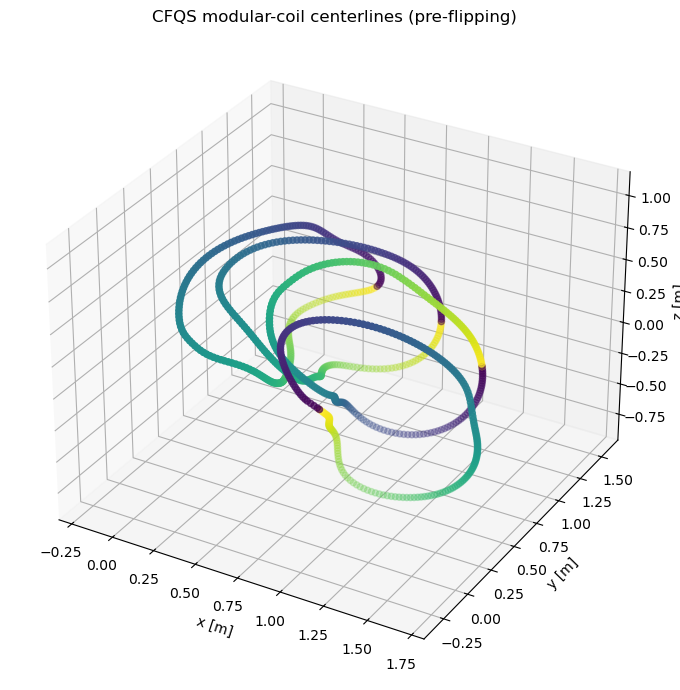

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
for name, g in zip(COIL_NAMES, coil_gammas_old):
    # Close the polyline visually for the plot only.
    loop = np.vstack([g, g[:1]])
    ax.scatter(loop[:, 0], loop[:, 1], loop[:, 2], c=np.arange(loop.shape[0]))
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("CFQS modular-coil centerlines (pre-flipping)")
# Equal aspect so the coils are not stretched.
all_pts = np.vstack(coil_gammas_old)
c = all_pts.mean(axis=0)
r = np.max(np.linalg.norm(all_pts - c, axis=1))
ax.set_xlim(c[0] - r, c[0] + r)
ax.set_ylim(c[1] - r, c[1] + r)
ax.set_zlim(c[2] - r, c[2] + r)
plt.tight_layout()
plt.show()


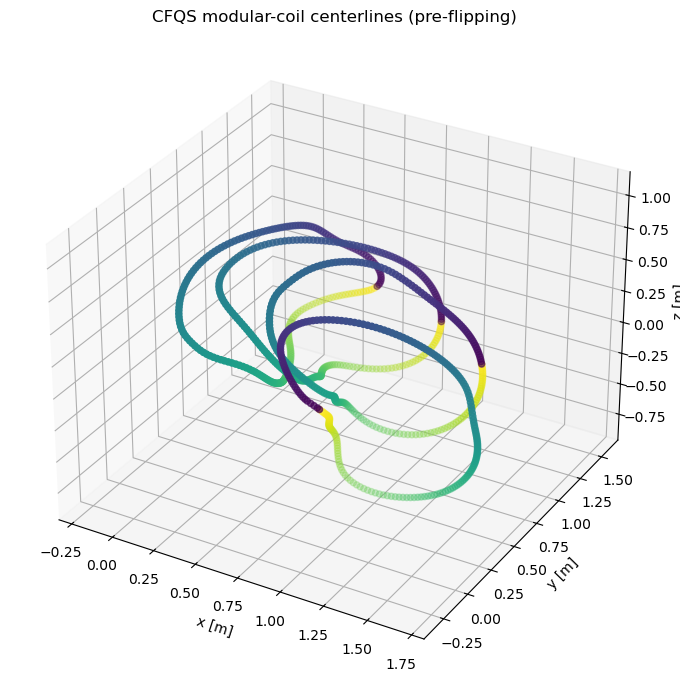

In [6]:
import matplotlib.pyplot as plt

coil_gammas = coil_gammas_old.copy()
coil_gammas[0] = np.flip(coil_gammas[0], axis=0)
coil_gammas[1] = np.flip(coil_gammas[1], axis=0)
shift = [np.argmax(c[:, 0]**2 + c[:, 1]**2) for c in coil_gammas]
coil_gammas = [np.roll(coil_gammas[i], shift[i])]
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
for name, g in zip(COIL_NAMES, coil_gammas):
    # Close the polyline visually for the plot only.
    loop = np.vstack([g, g[:1]])
    ax.scatter(loop[:, 0], loop[:, 1], loop[:, 2], c=np.arange(loop.shape[0]))
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("CFQS modular-coil centerlines (pre-flipping)")
# Equal aspect so the coils are not stretched.
all_pts = np.vstack(coil_gammas)
c = all_pts.mean(axis=0)
r = np.max(np.linalg.norm(all_pts - c, axis=1))
ax.set_xlim(c[0] - r, c[0] + r)
ax.set_ylim(c[1] - r, c[1] + r)
ax.set_zlim(c[2] - r, c[2] + r)
plt.tight_layout()
plt.show()


## Saving simsopt curves using utils provided by quadcoil


In [6]:
from quadcoil.io import curve_from_gamma
from quadcoil import SurfaceRZFourierJAX
from simsopt.geo import plot
from simsopt.field import Current, Coil
from simsopt import save

In [10]:
order = 10
base_coils = []
for i in range(len(coil_gammas_old)):
    gamma = coil_gammas_old[i]
    base_coils.append(Coil(
        curve=curve_from_gamma(gamma, order=10, ppp=20),
        current=Current(312.5e3) # 312.5kA
    ))

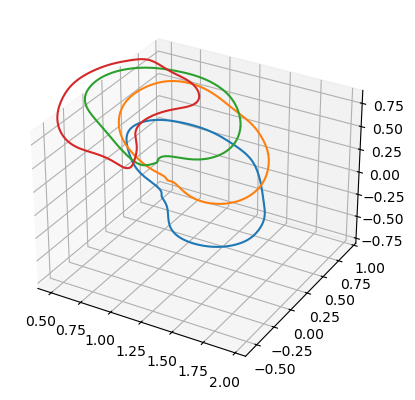

In [8]:
plot(base_coils)
save(base_coils, 'cfqs_base_coils.json')

## LCFS surface section (`2b40_o.stp`)

The fifth unique body is not a rectangular sweep: it is a sector of the
plasma boundary (LCFS), stored as B-spline surface patches plus two planar
cut faces. Below we pick the `+x,+y` field-period copy, UV-sample every
non-planar face, and stack the points into one `lcfs_gamma` of shape
`(n_point, 3)` in metres.

LCFS COM (mm): [721.5 581.9  82.9]
lcfs_gamma shape: (4480, 3) (metres)


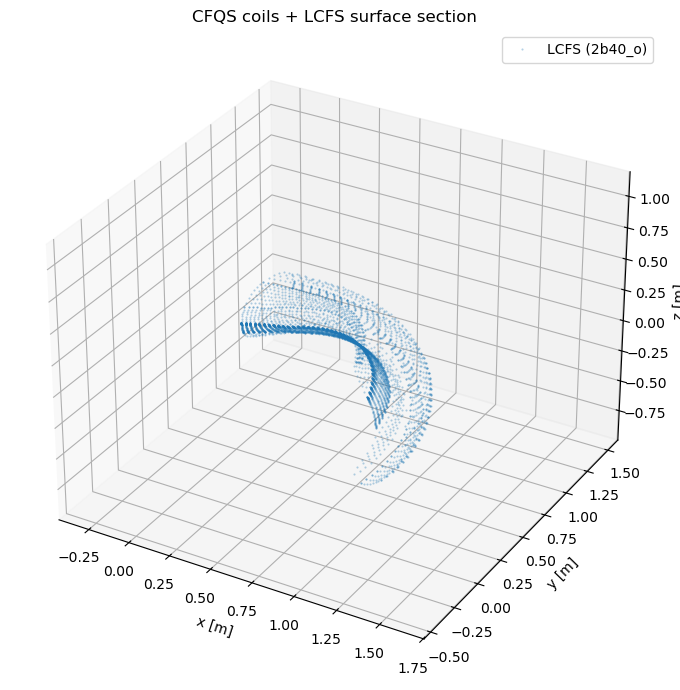

array([[ 1.14990000e+00,  1.91846539e-16,  0.00000000e+00],
       [ 1.14413392e+00,  3.83693077e-16, -7.44333247e-02],
       [ 1.12766883e+00,  7.88702437e-16, -1.47262249e-01],
       ...,
       [-3.74456022e-15,  9.15320002e-01,  1.74124916e-01],
       [-5.13722398e-15,  8.59154319e-01,  1.87423011e-01],
       [-7.81597009e-17,  8.01900000e-01,  1.94600000e-01]],
      shape=(4480, 3))

In [11]:
# LCFS = the unique solid with planar cut faces (not a rectangular tube).
# Reload the assembly (step_coils_to_gammas does not stash shapes).
reader = STEPControl_Reader()
if reader.ReadFile(STEP_PATH) != IFSelect_RetDone:
    raise RuntimeError(f"failed to read STEP file: {STEP_PATH}")
reader.TransferRoots()
assembly = reader.OneShape()

lcfs_solid = None
exp = TopExp_Explorer(assembly, TopAbs_SOLID)
while exp.More():
    solid = topods.Solid(exp.Current())
    props = GProp_GProps()
    brepgprop.VolumeProperties(solid, props)
    vol = props.Mass()
    com = np.asarray(props.CentreOfMass().Coord())
    has_plane = False
    face_exp = TopExp_Explorer(solid, TopAbs_FACE)
    while face_exp.More():
        if BRepAdaptor_Surface(topods.Face(face_exp.Current())).GetType() == GeomAbs_Plane:
            has_plane = True
            break
        face_exp.Next()
    # Large volume + planar caps → 2b40_o; keep one field period (+x, +y).
    if has_plane and vol > 1.0e8 and com[0] > 0.0 and com[1] > 0.0:
        lcfs_solid = solid
        lcfs_com_mm = com
        break
    exp.Next()
if lcfs_solid is None:
    raise RuntimeError("LCFS solid (2b40_o) not found in +x,+y")

# UV grid per curved face. U is shared across V-strips of the sector;
# NV_PER_FACE is small because the strips already tile V.
NU = 40
NV_PER_FACE = 8
pts_mm = []
face_exp = TopExp_Explorer(lcfs_solid, TopAbs_FACE)
while face_exp.More():
    face = topods.Face(face_exp.Current())
    surf = BRepAdaptor_Surface(face)
    if surf.GetType() == GeomAbs_Plane:
        face_exp.Next()
        continue
    u0, u1 = surf.FirstUParameter(), surf.LastUParameter()
    v0, v1 = surf.FirstVParameter(), surf.LastVParameter()
    for u in np.linspace(u0, u1, NU):
        for v in np.linspace(v0, v1, NV_PER_FACE):
            p = surf.Value(u, v)
            pts_mm.append([p.X(), p.Y(), p.Z()])
    face_exp.Next()

lcfs_gamma = np.asarray(pts_mm) * MM_TO_M  # (n_point, 3), metres
print(f"LCFS COM (mm): {np.round(lcfs_com_mm, 1)}")
print(f"lcfs_gamma shape: {lcfs_gamma.shape} (metres)")
assert lcfs_gamma.ndim == 2 and lcfs_gamma.shape[1] == 3

# Overlay on the coil centerlines for a quick sanity check.
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(lcfs_gamma[:, 0], lcfs_gamma[:, 1], lcfs_gamma[:, 2],
        ".", markersize=1, alpha=0.35, label="LCFS (2b40_o)")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("CFQS coils + LCFS surface section")
ax.legend()
all_pts = np.vstack([*coil_gammas_old, lcfs_gamma])
c = all_pts.mean(axis=0)
r = np.max(np.linalg.norm(all_pts - c, axis=1))
ax.set_xlim(c[0] - r, c[0] + r)
ax.set_ylim(c[1] - r, c[1] + r)
ax.set_zlim(c[2] - r, c[2] + r)
plt.tight_layout()
plt.show()

lcfs_gamma

In [17]:
from pathlib import Path
from simsopt.mhd import Vmec, VirtualCasing

In [30]:
vc_src_nphi = 40  # half fp like in virtual casing convention
vc_src_ntheta = 80
n_phi = 25
n_theta = 50

In [31]:
file_name = Path("./wout_cfqs_2b40_freeBoundary.nc")
"""Load a VMEC wout and build a half-fp virtual-casing plasma surface."""
eq = Vmec(file_name, keep_all_files=True)
vc = VirtualCasing.from_vmec(
    file_name,
    src_nphi=vc_src_nphi,
    src_ntheta=vc_src_ntheta,
    trgt_nphi=n_phi,
    trgt_ntheta=n_theta,
)
# This is a vacuum case!
Bnormal_plasma = vc.B_external_normal
plasma_surface = type(eq.boundary)(
    nfp=eq.boundary.nfp,
    stellsym=eq.boundary.stellsym,
    mpol=eq.boundary.mpol, ntor=eq.boundary.ntor,
    quadpoints_phi=np.linspace(0, 1/2/eq.boundary.nfp, n_phi, endpoint=False),
    quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
)
plasma_surface.set_dofs(eq.boundary.get_dofs())

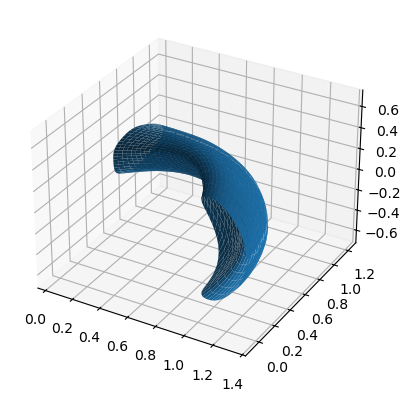

<Axes3D: >

In [32]:
plasma_surface.plot()

In [33]:
save({
    'base_coils': base_coils,
    'Bnormal_plasma': Bnormal_plasma,
    'plasma_surface': plasma_surface,
}, 'cfqs_data.json')